### Datos sinteticos 
### Libreria snv
*Fecha: 05 de junio*
*Autor: Abiel Antonio Ramos Chavez*

In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
import sdv
import sdmetrics

In [4]:
#importamos sublibrerias para la generacion de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [5]:
#importamos sub librerias para la evaluacion de datos
from sdmetrics.reports.single_table import QualityReport

In [8]:
print("SDV:", sdv.__version__)
print("SDMetrics:", sdmetrics.__version__)

SDV: 1.37.0
SDMetrics: 0.28.0


In [15]:
#Crear una tabla de datos real como base para la generacion de datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800,2000,2500,15000,18000,35000,7000,15000,4000,50000],
        "ciudad": ["Potrero", "Córdoba", "Orizaba", "Fortín de las Flores", "Cuitláhuac", "Yanga", "Amatlán de los Reyes", "Paso del Macho", "Coscomatepec", "Nogales"]
    }
)

### Obtener los metadata 

In [17]:
metadata = SingleTableMetadata()

In [21]:
metadata.detect_from_dataframe(
    data=dfClientes
)

In [22]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

In [28]:
import os

ruta_graphviz = r"C:\Users\Abiel\anaconda3\envs\entorno_sdv\Library\bin"
os.environ["PATH"] += os.pathsep + ruta_graphviz

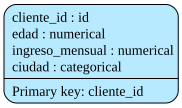

In [29]:
metadata.visualize()

### Entar el modelo de datos sinteticos 
*un sinthetisizer es el encargado de generar los datos sintéticos*

In [31]:
# Le pasamos los metadatos 
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\Abiel\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\Abiel\anaconda3\Lib\site-packages\sdv\single_table\base.py:138: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [33]:
#Entramos el sintetizador con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [36]:
# Generamos datos sinteticos 
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [37]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudad
0,9377199,18,2004,Potrero
1,2031974,18,3862,Cuitláhuac
2,5464438,18,2045,Córdoba
3,3224426,18,3410,Cuitláhuac
4,1760189,33,4679,Córdoba
...,...,...,...,...
195,15922112,25,4318,Yanga
196,7891214,20,10541,Cuitláhuac
197,3545532,38,43474,Nogales
198,15420883,22,6614,Paso del Macho


In [39]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,15030.000000
std,3.02765,16.063762,16050.202491
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,11000.000000
75%,7.75000,31.000000,17250.000000
max,10.00000,70.000000,50000.000000


In [40]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,7.964678e+06,26.945000,13321.505000
std,4.867522e+06,12.628514,13390.790299
min,1.896240e+05,18.000000,2000.000000
25%,3.527745e+06,18.000000,2403.000000
50%,7.562856e+06,20.000000,7370.000000
75%,1.269630e+07,32.250000,19082.750000
max,1.673568e+07,70.000000,48912.000000


### Evaluamos los datos para validar 
1. Parecido entre las columnas
2. Parecido entre las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluacion del dataset general 

In [41]:
#Evaluamos la calidad de los datos 
#Creamos una instancia de QualityReport
reporte = QualityReport()

### Puntos de referencia 
|Store | Interpretacion |
|------|----------------|
|1   | Indenticas |
|0.9 | My similar |
|0.7 | Similar |
|0.6 | Diferencias visibles|
|< 0.5 | Muy diferentes |

In [42]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 103.53it/s]|
Column Shapes Score: 83.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 62.20it/s]|
Column Pair Trends Score: 30.5%

Overall Score (Average): 56.75%

